In [1]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Helvetica'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
import fly_plot_lib.plot as fpl

import scipy.stats

In [3]:
from splitflow import unifying_algo_analysis_helper as uaah
from splitflow.set_zorder_functions import *

Using device: cpu


In [4]:
from align_course_direction_analysis import unifying_algo_analysis as uaa
from align_course_direction_analysis import unifying_algo_plots as uap

In [5]:
MARKERSIZE = 0.75
MODEL_LINE_COLOR = 'lightcoral'
TRANSLATION = True

In [6]:
FIGURE_NAME = 'unifying_analysis.svg'

In [7]:
if TRANSLATION:
    FIGURE_NAME = 'unifying_analysis_translationTrue.svg'

In [8]:
def get_median_slope_and_axis_ratio(fname):
    df = pd.read_parquet(fname)

    slopes = []
    axis_ratios = []
    rotation = []

    for obj_id in df.obj_id_unique_event.unique():
        data = df[df.obj_id_unique_event==obj_id].copy()
        #slopes.append(data.slope.abs().median())

        data['slope_abs'] = data.slope.abs()
        slopes.append( uaa.get_weighted_value(data, col='slope_abs', use='rmse_affine') )

        axis_ratios.append( uaa.get_weighted_value(data, col='axis_ratio', use='rmse_affine') )

        data.rotation = data.rotation.abs()
        rotation.append( uaa.get_weighted_value(data, col='rotation', use='rmse_affine') )

            
    results = {'slopes': np.array(slopes)/0.01,
               'axis_ratios': np.array(axis_ratios),
               'rotation': np.array(rotation),
               #'percent_affine_improvements': np.array(percent_affine_improvements),
              }
    
    return results

In [9]:
df = pd.read_parquet('../../../../Data/Experimental_Fly_Data/flies_varwind_C1WT_combined_optotrigger_fancontrol_trimmed.parquet')

In [10]:
df.fan_speed_percent.unique()

array([28., 23., nan, 20., 12., 40., 90.])

In [11]:
metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_12.0_translation' + str(TRANSLATION) + '.parquet': [1, 'gray', 'low', 0], 
            '../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_20.0_translation' + str(TRANSLATION) + '.parquet': [2, 'gray', 'low', 0.03],
            '../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_23.0_translation' + str(TRANSLATION) + '.parquet': [3, 'gray', 'low', 0.1],
            '../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_28.0_translation' + str(TRANSLATION) + '.parquet': [4, '#bd7bffff', 'low', 0.2],
            '../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_40.0_translation' + str(TRANSLATION) + '.parquet': [5, 'gray', 'low', 0.3],
            '../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_90.0_translation' + str(TRANSLATION) + '.parquet': [6, 'gray', 'low', 0.6],
           }

In [12]:
# metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_12.0_translationFalse' + '.parquet': [1, 'gray', 'low', 0], 
#             '../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_20.0_translationFalse' + '.parquet': [2, 'gray', 'low', 0.03],
#             '../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_23.0_translationFalse' + '.parquet': [3, 'gray', 'low', 0.1],
#             '../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_28.0_translationFalse' + '.parquet': [4, '#a245ffff', 'low', 0.2],
#             '../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_40.0_translationFalse' + '.parquet': [5, 'gray', 'low', 0.3],
#             '../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_90.0_translationFalse' + '.parquet': [6, 'gray', 'low', 0.6],
#            }

In [13]:
results = get_median_slope_and_axis_ratio('../../../../Data/Unifying_Algo_Results/Supplemental/' + 'varwind_N700_flash_90.0_translationFalse' + '.parquet')['slopes']
print(len(results))

241


In [14]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

median slope:  3.5956978903130628


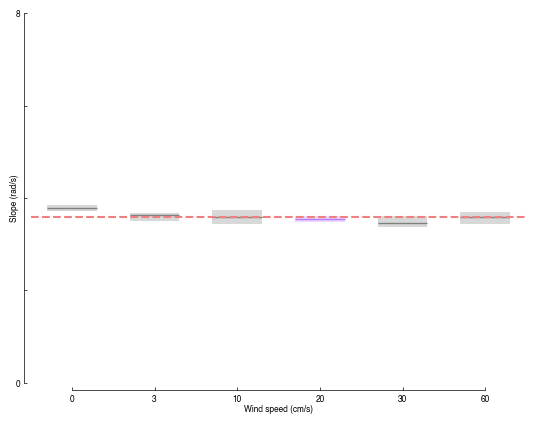

In [15]:
if 0:
    ax = layout.axes[('variable_wind', 'slopes')]
else:
    fig = plt.figure()
    ax = fig.add_subplot(111)


feature = 'slopes'

x_data_for_regression = []
y_data_for_regression = []

ticks = []
ticklabels = []

dpoints = []
speedpoints = []
for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label, speed = val

    ticks.append(xix)
    ticklabels.append(speed)
    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), 
                                        hist_counts, hist_bins, color=color, markersize=MARKERSIZE,
                                       hide_markers=True)

    dpoints.append(results[feature])
    speedpoints.append(np.ones_like(results[feature])*speed)
    
    if xix<=6:
        x_data_for_regression.append(xix)
        y_data_for_regression.append(np.median(results[feature]))

print('median slope: ', np.median(y_data_for_regression))
median_slope = np.median(y_data_for_regression)
xixs = [1,2,3,4,5,6]
ax.hlines([median_slope,],
          xixs[0]-0.5, xixs[-1]+0.5, 
          linestyles=['--',], colors=[MODEL_LINE_COLOR,])

ax.set_xlim(0.5, 6.5)
ax.set_ylim(0,8)

ax.set_ylabel('Slope (rad/s)', labelpad=-2)
ax.set_xlabel('Wind speed (cm/s)', labelpad=1)

ax.set_xticks(ticks)
#def to_latex_math(items):
#    return [f'${x}$' for x in items]
ax.set_xticklabels([0, 3, 10, 20, 30, 60])

ax.set_yticks([0, 2, 4, 6, 8])
ax.set_yticklabels(['0', '', '', '', '8'])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)

# data = diagnose_axis_elements(ax, verbose=True)
set_selective_rasterization(ax, rasterize_markers=['o'])

#ax.set_rasterization_zorder(1000)

# Kruskal Wallis test

In [16]:
scipy.stats.kruskal(dpoints[0], dpoints[1],dpoints[2])

KruskalResult(statistic=np.float64(17.76195229211862), pvalue=np.float64(0.00013900840680383778))

# Cohens-d

For the largest effect size -- between 0 and 30 cm/s

In [17]:
(np.median(dpoints[0]) - np.median(dpoints[3]) ) / np.std( np.hstack((dpoints[0], dpoints[3])) )

np.float64(0.22766877955993403)

# Linear regression

Note small p-val yet tiny effect size

In [18]:
scipy.stats.linregress(np.hstack(speedpoints), np.hstack(dpoints))

LinregressResult(slope=np.float64(-0.5127484706230167), intercept=np.float64(3.5881311809387904), rvalue=np.float64(-0.07651391742756797), pvalue=np.float64(7.785802002087065e-05), stderr=np.float64(0.12957755139374993), intercept_stderr=np.float64(0.029959624755276))

# Equivalence test

   Group 1    Group 2      δ  Median diff  CI low (90%)  CI high (90%)  Within ±δ
   Group 0 Group 0.03 0.5509       0.1621        0.0876         0.2597       True
   Group 0  Group 0.1 0.5740       0.1889        0.0736         0.3093       True
   Group 0  Group 0.2 0.5378       0.2473        0.1636         0.3336       True
   Group 0  Group 0.3 0.5814       0.3175        0.1954         0.4159       True
   Group 0  Group 0.6 0.5754       0.1900        0.0881         0.3546       True
Group 0.03  Group 0.1 0.6092       0.0268       -0.1032         0.1365       True
Group 0.03  Group 0.2 0.5730       0.0852       -0.0136         0.1627       True
Group 0.03  Group 0.3 0.6166       0.1554        0.0233         0.2465       True
Group 0.03  Group 0.6 0.6106       0.0279       -0.0913         0.1838       True
 Group 0.1  Group 0.2 0.5961       0.0584       -0.0628         0.1757       True
 Group 0.1  Group 0.3 0.6397       0.1286       -0.0244         0.2581       True
 Group 0.1  Grou

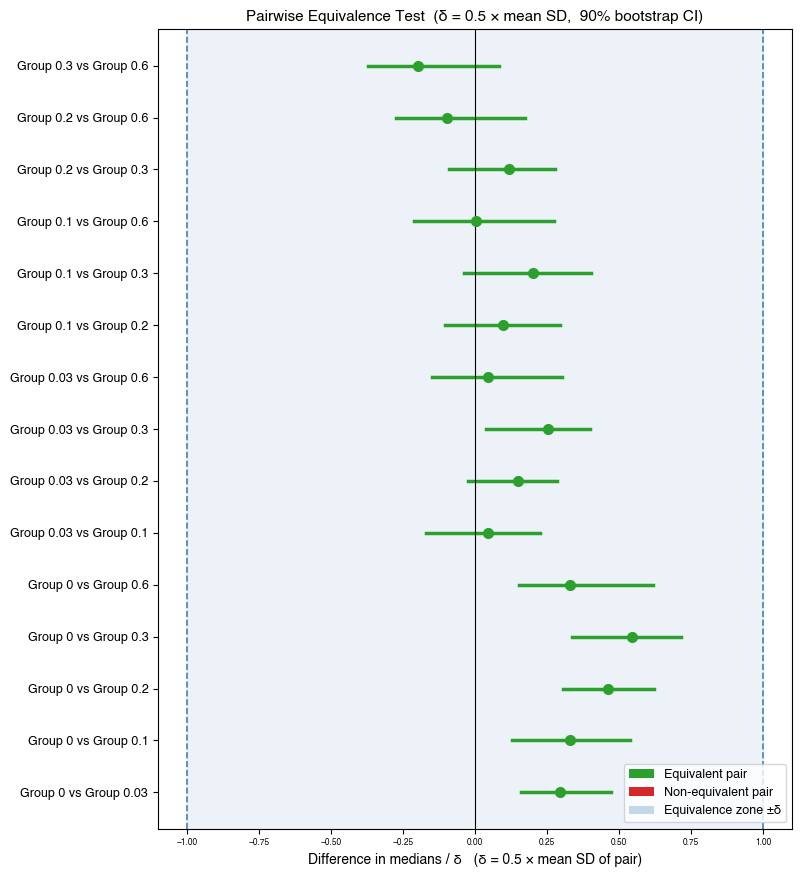

In [19]:
import numpy as np
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt


# ── Core functions ────────────────────────────────────────────────────────────

def _bootstrap_median_diff_ci(group1, group2, alpha, n_bootstrap, rng):
    """Bootstrap (1 - 2*alpha) CI for the difference in medians."""
    boot_diffs = np.array([
        np.median(rng.choice(group1, len(group1), replace=True)) -
        np.median(rng.choice(group2, len(group2), replace=True))
        for _ in range(n_bootstrap)
    ])
    ci_low  = np.percentile(boot_diffs, 100 * alpha)
    ci_high = np.percentile(boot_diffs, 100 * (1 - alpha))
    obs_diff = np.median(group1) - np.median(group2)
    return obs_diff, ci_low, ci_high


def equivalence_test(groups, group_names, delta=None, delta_factor=None,
                     alpha=0.05, n_bootstrap=10_000, random_state=42):
    """
    Non-parametric pairwise equivalence test using bootstrap TOST.

    Uses the intersection-union test (IUT): overall equivalence is declared
    only when *all* pairwise comparisons are equivalent. IUT controls the
    familywise error rate at alpha without Bonferroni correction.

    The equivalence threshold delta can be specified two ways:
      - Fixed:    delta=<float>  — same threshold for every pair (original units)
      - Relative: delta_factor=<float>  — per-pair threshold computed as
                  delta_factor * mean(std(g1), std(g2))
                  e.g. delta_factor=1.0 supports the statement
                  "all group medians were within 1 SD of each other"

    Parameters
    ----------
    groups : list of array-like
        One array per group.
    group_names : list of str
        Display names for each group.
    delta : float or None
        Fixed equivalence threshold in the same units as your data.
    delta_factor : float or None
        Per-pair threshold as a multiple of the mean SD of the two groups.
        Provide either delta or delta_factor, not both.
    alpha : float
        Per-comparison significance level (default 0.05).
    n_bootstrap : int
        Number of bootstrap resamples (default 10 000).
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    results : pd.DataFrame
        One row per pair with δ, observed difference, CI bounds, and verdict.
    overall_equivalent : bool
        True only if every pairwise comparison is within its δ.
    """
    if (delta is None) == (delta_factor is None):
        raise ValueError("Provide exactly one of: delta (fixed) or delta_factor (SD-relative).")

    rng = np.random.default_rng(random_state)
    ci_label = f"{(1 - 2 * alpha) * 100:.0f}%"

    rows = []
    for i, j in combinations(range(len(groups)), 2):
        g1 = np.asarray(groups[i], dtype=float)
        g2 = np.asarray(groups[j], dtype=float)

        # Per-pair delta
        if delta_factor is not None:
            delta_ij = delta_factor * np.mean([np.std(g1, ddof=1),
                                               np.std(g2, ddof=1)])
        else:
            delta_ij = float(delta)

        obs_diff, ci_low, ci_high = _bootstrap_median_diff_ci(
            g1, g2, alpha, n_bootstrap, rng
        )
        equivalent = (ci_low > -delta_ij) and (ci_high < delta_ij)

        rows.append({
            "Group 1":               group_names[i],
            "Group 2":               group_names[j],
            "δ":                     round(delta_ij, 4),
            "Median diff":           round(obs_diff,  4),
            f"CI low ({ci_label})":  round(ci_low,    4),
            f"CI high ({ci_label})": round(ci_high,   4),
            "Within ±δ":             equivalent,
        })

    results = pd.DataFrame(rows)
    overall_equivalent = bool(results["Within ±δ"].all())
    return results, overall_equivalent


# ── Visualisation ─────────────────────────────────────────────────────────────

def plot_equivalence(results, delta_factor=None, alpha=0.05):
    """
    Forest plot of pairwise equivalence results.

    All values are normalised by each pair's δ so the equivalence zone is
    always ±1 on the x-axis, regardless of varying per-pair thresholds.
    Green intervals fall entirely within ±1 (equivalent); red cross a bound.
    """
    ci_label = f"{(1 - 2 * alpha) * 100:.0f}%"
    col_low  = f"CI low ({ci_label})"
    col_high = f"CI high ({ci_label})"

    n = len(results)
    fig, ax = plt.subplots(figsize=(8, max(3, n * 0.45 + 2)))

    for idx, row in results.iterrows():
        d = row["δ"]
        # Normalise by delta so equivalence zone is always ±1
        x_diff = row["Median diff"] / d
        x_low  = row[col_low]  / d
        x_high = row[col_high] / d

        color = "#2ca02c" if row["Within ±δ"] else "#d62728"
        ax.plot([x_low, x_high], [idx, idx], color=color, lw=2.5)
        ax.plot(x_diff, idx, "o", color=color, ms=7, zorder=3)

    # Equivalence zone is always ±1 after normalisation
    ax.axvspan(-1, 1, color="steelblue", alpha=0.10)
    ax.axvline(-1, color="steelblue", lw=1.2, linestyle="--")
    ax.axvline( 1, color="steelblue", lw=1.2, linestyle="--")
    ax.axvline( 0, color="black",     lw=0.8)

    pair_labels = [f"{r['Group 1']} vs {r['Group 2']}"
                   for _, r in results.iterrows()]
    ax.set_yticks(range(n))
    ax.set_yticklabels(pair_labels, fontsize=9)

    if delta_factor is not None:
        ax.set_xlabel(
            f"Difference in medians / δ   "
            f"(δ = {delta_factor} × mean SD of pair)",
            fontsize=10
        )
        title_delta = f"δ = {delta_factor} × mean SD"
    else:
        fixed_delta = results["δ"].iloc[0]
        ax.set_xlabel("Difference in medians / δ", fontsize=10)
        title_delta = f"δ = {fixed_delta}"

    ax.set_title(
        f"Pairwise Equivalence Test  ({title_delta},  "
        f"{ci_label} bootstrap CI)",
        fontsize=11
    )

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ca02c", label="Equivalent pair"),
        Patch(facecolor="#d62728", label="Non-equivalent pair"),
        Patch(facecolor="steelblue", alpha=0.3, label="Equivalence zone ±δ"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
    plt.tight_layout()
    return fig


# ── Example usage ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    groups = dpoints
    group_names = [f"Group {c}" for c in ticklabels]

    # ── Option A: SD-relative delta (recommended) ─────────────────────────────
    # Supports statements like:
    #   "All group medians were within 0.5 SDs of every other group (TOST, α=0.05)"
    delta_factor = 0.5   # try 0.5 or 1.0

    results, overall = equivalence_test(
        groups, group_names,
        delta_factor=delta_factor,
        alpha=0.05,
        n_bootstrap=10_000,
        random_state=42,
    )

    # ── Option B: Fixed delta ─────────────────────────────────────────────────
    # results, overall = equivalence_test(
    #     groups, group_names,
    #     delta=0.3,
    #     alpha=0.05,
    #     n_bootstrap=10_000,
    #     random_state=42,
    # )

    print(results.to_string(index=False))
    print(f"\nOverall equivalence (IUT): {'YES ✓' if overall else 'NO ✗'}")

    fig = plot_equivalence(results, delta_factor=delta_factor)
    plt.savefig("equivalence_test.png", dpi=150, bbox_inches="tight")
    plt.show()

# Axis ratio analysis

In [20]:
ax = layout.axes[('variable_wind', 'axis_ratios')]

feature = 'axis_ratios'

x_data_for_regression = []
y_data_for_regression = []

ticks = []
ticklabels = []

dpoints = []
for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label, speed = val

    ticks.append(xix)
    ticklabels.append(label)

    print(key)
    print(len(results[feature]))
    print('')
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)

    dpoints.append(results[feature])  
    
    if xix<=6:
        x_data_for_regression.append(xix)
        y_data_for_regression.append(np.median(results[feature]))

result = scipy.stats.linregress(x_data_for_regression, y_data_for_regression)
axis_ratio_slope = result.slope
axis_ratio_intercept = result.intercept
x = np.linspace(x_data_for_regression[0]-0.5, x_data_for_regression[-1]+0.5, 10)
y = x*axis_ratio_slope + axis_ratio_intercept
ax.plot(x, y, '--', color=MODEL_LINE_COLOR)

print('axis ratios')
print(x_data_for_regression)
print(y_data_for_regression)

model_axis_ratio = {}
for key, val in metadata.items():
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label, speed = val
    model_axis_ratio_for_condition = xix*axis_ratio_slope + axis_ratio_intercept
    model_axis_ratio.setdefault(fname, model_axis_ratio_for_condition)

print('axis_ratio_slope: ', axis_ratio_slope)
print('axis_ratio_intercept: ', axis_ratio_intercept)

ax.set_xlim(0.5, 6.5)
ax.set_ylim(0,1)

ax.set_ylabel('Axis ratio', labelpad=-2)

ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0', '', '', '', '', '1'])

ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)
set_selective_rasterization(ax, rasterize_markers=['o'])

../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_12.0_translationTrue.parquet
700



../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_20.0_translationTrue.parquet
491

../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_23.0_translationTrue.parquet
257



../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_28.0_translationTrue.parquet
700

../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_40.0_translationTrue.parquet
272



../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_90.0_translationTrue.parquet
241

axis ratios
[1, 2, 3, 4, 5, 6]
[np.float64(0.682934699550005), np.float64(0.6365134696963373), np.float64(0.47095793849499484), np.float64(0.49548048641991316), np.float64(0.3575208154127715), np.float64(0.2389559723535617)]


axis_ratio_slope:  -0.086638544311657
axis_ratio_intercept:  0.7836288020787301


In [21]:

"""
Paste this cell after the slope plotting cell (cell 61 in the notebook),
which ends with `set_selective_rasterization(ax, rasterize_markers=['o'])`.

It assumes `dpoints` is a list of 3 arrays: [laminar_slopes, unsteady_slopes, stillair_slopes],
which is built in that cell via `dpoints.append(results[feature])`.
"""

import numpy as np
import scipy.stats
from itertools import combinations

# =============================================================================
# Verify data is available
# =============================================================================
assert len(dpoints) == 6, f"Expected 6 conditions in dpoints, got {len(dpoints)}"
condition_labels = ['12', '20', '23', '28', '40', '90']

print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
for i, label in enumerate(condition_labels):
    d = dpoints[i]
    print(f"  {label:>10s}: n={len(d)}, mean={np.mean(d):.3f}, median={np.median(d):.3f}, sd={np.std(d):.3f}")

# =============================================================================
# Jonckheere-Terpstra (ordered trend: laminar < unsteady < stillair)
# =============================================================================
def jonckheere_terpstra(groups):
    """
    Jonckheere-Terpstra test for an increasing trend across ordered groups.
    groups: list of arrays in hypothesized order.
    """
    k = len(groups)
    J = 0
    for i, j in combinations(range(k), 2):
        for xi in groups[i]:
            for xj in groups[j]:
                if xj > xi:
                    J += 1
                elif xj == xi:
                    J += 0.5

    n = [len(g) for g in groups]
    N = sum(n)
    E_J = (N**2 - sum(ni**2 for ni in n)) / 4
    Var_J = (N**2 * (2 * N + 3) - sum(ni**2 * (2 * ni + 3) for ni in n)) / 72

    Z = (J - E_J) / np.sqrt(Var_J)
    p_one = scipy.stats.norm.cdf(Z)
    p_two = 2 * min(p_one, 1 - p_one)

    return J, E_J, Z, p_one, p_two

J, E_J, Z, p_one, p_two = jonckheere_terpstra(dpoints)

print("\n" + "=" * 60)
print("Jonckheere-Terpstra (ordered: still air to laminar")
print("=" * 60)
print(f"  J = {J:.1f}")
print(f"  E[J] = {E_J:.1f}")
print(f"  Z = {Z:.4f}")
print(f"  p (one-sided, decreasing) = {p_one:.2e}")
print(f"  p (two-sided) = {p_two:.2e}")



# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Hypothesized order: still air to laminar")
print(f"  Group medians: {[f'{np.median(d):.3f}' for d in dpoints]}")
print(f"")
print(f"  Jonckheere-Terpstra p (one-sided): {p_one:.2e}")


DATA SUMMARY
          12: n=700, mean=0.639, median=0.683, sd=0.187
          20: n=491, mean=0.598, median=0.637, sd=0.200
          23: n=257, mean=0.485, median=0.471, sd=0.211
          28: n=700, mean=0.497, median=0.495, sd=0.213
          40: n=272, mean=0.397, median=0.358, sd=0.203
          90: n=241, mean=0.256, median=0.239, sd=0.145

Jonckheere-Terpstra (ordered: still air to laminar
  J = 864682.0
  E[J] = 1415431.5
  Z = -24.6334
  p (one-sided, decreasing) = 2.77e-134
  p (two-sided) = 5.54e-134

SUMMARY
  Hypothesized order: still air to laminar
  Group medians: ['0.683', '0.637', '0.471', '0.495', '0.358', '0.239']

  Jonckheere-Terpstra p (one-sided): 2.77e-134


In [22]:
for key, val in metadata.items():
    print(key)

    for speed_str in ['12', '28', '90']:
        if speed_str in key: # or '28' in key or '90' in key:
            df = pd.read_parquet(key)
            print(len(df.obj_id_unique_event.unique()))
            
            item = layout.svgitems['text_n_var_'+speed_str]
            N_trajecs = len(df.obj_id_unique_event.unique())
            item.text = 'n=' + str(N_trajecs)

    

../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_12.0_translationTrue.parquet


700
../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_20.0_translationTrue.parquet
../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_23.0_translationTrue.parquet
../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_28.0_translationTrue.parquet
700
../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_40.0_translationTrue.parquet
../../../../Data/Unifying_Algo_Results/Supplemental/varwind_N700_flash_90.0_translationTrue.parquet
241


In [23]:
layout.apply_svg_attrs()
layout.append_figure_to_layer(layout.figures['variable_wind'], 'variable_wind', cleartarget=True)
layout.write_svg(FIGURE_NAME)